# IMPORTS

In [9]:
import os
from datasets import load_dataset, Image, load_from_disk
import multiprocessing as mp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle as pkl
from collections import Counter
from tqdm import tqdm
from torchvision import transforms
import torch

# CONFIGURATIONS

In [7]:
# Load data
image_folder = "/kaggle/input/im2latex100k/formula_images_processed/formula_images_processed"  # Thay bằng đường dẫn folder ảnh của bạn
data_files = {
    "train": "/kaggle/input/im2latex100k/im2latex_train.csv",
    "validation": "/kaggle/input/im2latex100k/im2latex_validate.csv",
    "test": "/kaggle/input/im2latex100k/im2latex_test.csv"
}

NUM_PROC = mp.cpu_count()   

# Formula processing
START_TOKEN_ID = 0
PAD_TOKEN_ID = 1
END_TOKEN_ID = 2
UNK_TOKEN_ID = 3

# Save Path
DATASET_SAVE_PATH = 'dataset'
VOCAB_SAVE_PATH = 'vocab.pkl'

# FILTER
MAX_TOKEN = 150
MIN_COUNT = 10 # Vocab

# LOAD DATA

In [8]:
dataset = load_dataset("csv", data_files=data_files)

In [9]:
def update_image_path(example):
    example['image'] = os.path.join(image_folder, example['image'])
    return example

dataset = dataset.map(update_image_path)

In [10]:
dataset = dataset.cast_column("image", Image())

In [11]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['formula', 'image'],
        num_rows: 75275
    })
    validation: Dataset({
        features: ['formula', 'image'],
        num_rows: 8370
    })
    test: Dataset({
        features: ['formula', 'image'],
        num_rows: 10355
    })
})


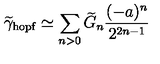

In [12]:
dataset['train']['image'][0] 

In [13]:
dataset['train']['formula'][0]

'\\widetilde \\gamma _ { \\mathrm { h o p f } } \\simeq \\sum _ { n > 0 } \\widetilde { G } _ { n } { \\frac { ( - a ) ^ { n } } { 2 ^ { 2 n - 1 } } }'

In [14]:
def get_size(example):
    w, h = example['image'].size
    return {'width': w, 'height': h}


dataset = dataset.map(
    get_size,
    num_proc=NUM_PROC,
    desc="Extracting original sizes",
)

Extracting original sizes (num_proc=4):   0%|          | 0/75275 [00:00<?, ? examples/s]

Extracting original sizes (num_proc=4):   0%|          | 0/8370 [00:00<?, ? examples/s]

Extracting original sizes (num_proc=4):   0%|          | 0/10355 [00:00<?, ? examples/s]

# EDA

In [37]:
heights = np.array(dataset['train']['height'])
widths = np.array(dataset['train']['width'])
pixels = heights * widths
ratios = widths / heights

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Image widths stats:
- Min: 128
- Max: 480
- Mean: 281.25
- Median: 256.0
- Std: 108.43
Index min width:  [    3    13    15 ... 75242 75244 75252]
Index max width:  [    5     7    14 ... 75238 75250 75268]


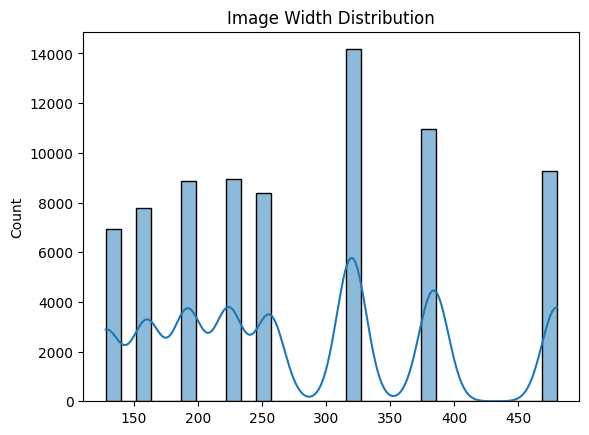

In [38]:
sns.histplot(widths, bins=30, kde=True).set(title="Image Width Distribution")
print("Image widths stats:")
print(f"- Min: {widths.min()}")
print(f"- Max: {widths.max()}")
print(f"- Mean: {widths.mean():.2f}")
print(f"- Median: {np.median(widths)}")
print(f"- Std: {widths.std():.2f}")
print("Index min width: ", np.where(widths == 128)[0])
print("Index max width: ", np.where(widths == 480)[0])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Image heights stats:
- Min: 32
- Max: 160
- Mean: 52.87
- Median: 64.0
- Std: 17.02
Index min height:  [    1     4     6 ... 75271 75273 75274]
Index max height:  [  322  2399  2818  3177  5461  9315  9734 10657 13923 17725 20771 21654
 23769 24745 28142 28229 32163 36784 37468 39059 39443 40006 43121 47111
 49993 50650 51352 54492 59819 59948 62464 64214 67777 69858 73856 74679]


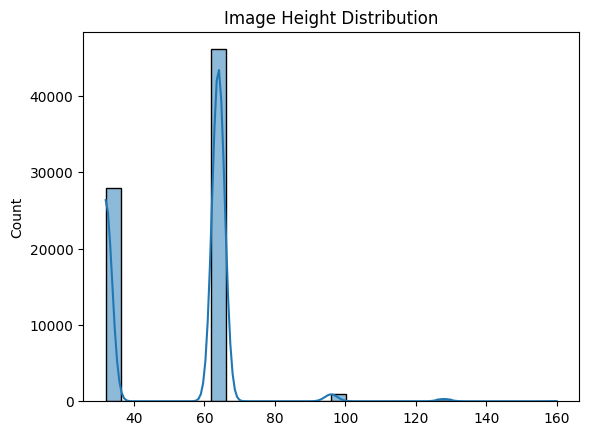

In [39]:
sns.histplot(heights, bins=30, kde=True).set(title="Image Height Distribution")
print("Image heights stats:")
print(f"- Min: {heights.min()}")
print(f"- Max: {heights.max()}")
print(f"- Mean: {heights.mean():.2f}")
print(f"- Median: {np.median(heights)}")
print(f"- Std: {heights.std():.2f}")
print("Index min height: ", np.where(heights == 32)[0])
print("Index max height: ", np.where(heights == 160)[0])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Width/Height ratios stats:
- Min: 2.00
- Max: 15.00
- Mean: 5.83
- Median: 5.00
- Std: 2.87
Index min Width/Height ratio:  [    3    13    28 ... 75214 75244 75252]
Index max Width/Height ratio:  [   21    26    36 ... 75227 75238 75268]


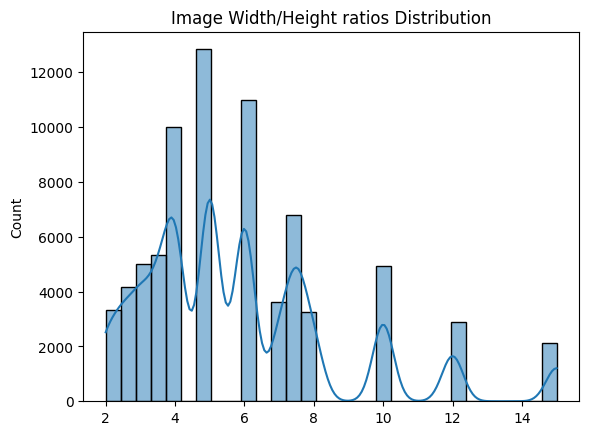

In [40]:
sns.histplot(ratios, bins=30, kde=True).set(title="Image Width/Height ratios Distribution")
print("Width/Height ratios stats:")
print(f"- Min: {ratios.min():.2f}")
print(f"- Max: {ratios.max():.2f}")
print(f"- Mean: {ratios.mean():.2f}")
print(f"- Median: {np.median(ratios):.2f}")
print(f"- Std: {ratios.std():.2f}")
print("Index min Width/Height ratio: ", np.where(ratios == 2)[0])
print("Index max Width/Height ratio: ", np.where(ratios == 15)[0])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0.98, 'Scatter plot for width and height')

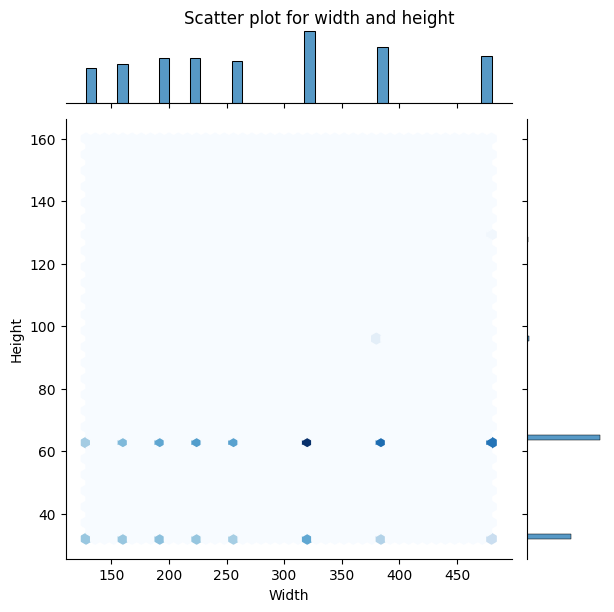

In [41]:
plot = sns.jointplot(x=widths, y=heights, kind="hex", cmap="Blues")
plt.subplots_adjust(top=0.95)
plot.set_axis_labels(xlabel="Width", ylabel="Height")
plot.fig.suptitle("Scatter plot for width and height")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Image pixels stats:
- Min: 4096
- Max: 76800
- Mean: 15276.01
- Median: 12288.0
- Std: 8747.58
Index min pixel:  [   15    56    64 ... 75230 75236 75242]
Index max pixel:  [  322  2399  2818  3177  5461  9315  9734 10657 13923 17725 20771 21654
 23769 24745 28142 28229 32163 36784 37468 39059 39443 40006 43121 47111
 49993 50650 51352 54492 59819 59948 62464 64214 67777 69858 73856 74679]


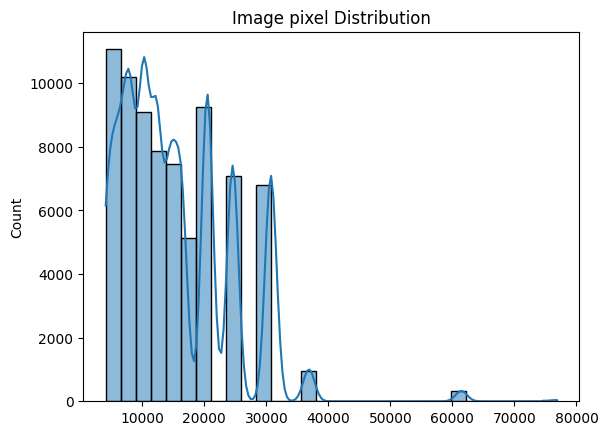

In [42]:
sns.histplot(pixels, bins=30, kde=True).set(title="Image pixel Distribution")
print("Image pixels stats:")
print(f"- Min: {pixels.min()}")
print(f"- Max: {pixels.max()}")
print(f"- Mean: {pixels.mean():.2f}")
print(f"- Median: {np.median(pixels)}")
print(f"- Std: {pixels.std():.2f}")
print("Index min pixel: ", np.where(pixels == 4096)[0])
print("Index max pixel: ", np.where(pixels == 76800)[0])

In [43]:
for split in dataset.keys():
    N = len(dataset[split])
    for i in range (N):
        if dataset[split]['formula'][i] is None:
            print(f"Wrong sample's index in {split}:", i)

Wrong sample's index in test: 485
Wrong sample's index in test: 574
Wrong sample's index in test: 591
Wrong sample's index in test: 730
Wrong sample's index in test: 858
Wrong sample's index in test: 930
Wrong sample's index in test: 1237
Wrong sample's index in test: 1265
Wrong sample's index in test: 1432
Wrong sample's index in test: 1496
Wrong sample's index in test: 1605
Wrong sample's index in test: 1698
Wrong sample's index in test: 1897
Wrong sample's index in test: 1998
Wrong sample's index in test: 2194
Wrong sample's index in test: 2265
Wrong sample's index in test: 2457
Wrong sample's index in test: 2518
Wrong sample's index in test: 2529
Wrong sample's index in test: 2540
Wrong sample's index in test: 2620
Wrong sample's index in test: 2696
Wrong sample's index in test: 2710
Wrong sample's index in test: 2985
Wrong sample's index in test: 3077
Wrong sample's index in test: 3364
Wrong sample's index in test: 3489
Wrong sample's index in test: 3504
Wrong sample's index in te

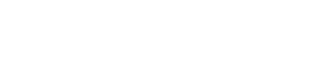

In [44]:
dataset['test']['image'][10210]

In [45]:
print(dataset['test']['formula'][10210])

None


# FILTER DATASET

In [ ]:
dataset = dataset.filter(lambda x: x['formula'] is not None and x['formula'] != "" and len(x['formula'].split()) <= MAX_TOKEN)

In [ ]:
for split in dataset.keys():
    N = len(dataset[split])
    for i in range (N):
        if dataset[split]['formula'][i] is None:
            print(f"Wrong sample's index in {split}:", i)

In [ ]:
dataset

# BUILD VOCAB

In [ ]:
class Vocab(object):
    def __init__(self):
        self.sign2id = {
            "<s>": START_TOKEN_ID,
            "</s>": END_TOKEN_ID,
            "<pad>": PAD_TOKEN_ID,
            "<unk>": UNK_TOKEN_ID
        }
        self.id2sign = dict((idx, token) for token, idx in self.sign2id.items())
        self.length = 4

    def add_sign(self, sign):
        if sign not in self.sign2id:
            self.sign2id[sign] = self.length
            self.id2sign[self.length] = sign
            self.length += 1

    def __len__(self):
        return self.length

def build_vocab(hf_train_dataset, save_path='vocab.pkl', min_count=10):
    """
    Xây dựng bộ từ điển từ Hugging Face Dataset (tập train)
    """
    vocab = Vocab()
    counter = Counter()

    print("Đang đếm từ trong tập train...")

    
    for sample in tqdm(hf_train_dataset):
        formula = sample['formula']
        tokens = formula.strip().split() 
        counter.update(tokens)

    print(f"Tổng số token tìm thấy (chưa lọc): {len(counter)}")
    count_filtered = 0
    for word, count in counter.most_common():
        if count >= min_count:
            vocab.add_sign(word)
        else:
            count_filtered += 1
            
    print(f"Đã lọc bỏ {count_filtered} token xuất hiện dưới {min_count} lần.")
    print(f"Kích thước từ điển cuối cùng: {len(vocab)}")
    
    return vocab

In [ ]:
vocab = build_vocab(dataset['train'], save_path='vocab.pkl', min_count=MIN_COUNT)
    
print("\nTest thử ID của một vài ký tự:")
test_tokens = ['\\alpha', '=', '1', '<pad>', 'token_lung_tung']
for t in test_tokens:
    token_id = vocab.sign2id.get(t, vocab.sign2id['<unk>'])
    print(f"'{t}' -> {token_id}")

In [ ]:
dataset.save_to_disk(DATASET_SAVE_PATH)
with open(VOCAB_SAVE_PATH, 'wb') as w:
    pkl.dump(vocab, w)

# Statistics

In [5]:
dataset = load_from_disk("/kaggle/input/im2latex-100k/dataset")

In [22]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(), 
])

sum = torch.tensor([0.0, 0.0, 0.0])
sum_sq = torch.tensor([0.0, 0.0, 0.0])
count = 0

print(f"Đang tính toán trên tập: train...")

for item in tqdm(dataset['train']):
    img = item['image']
    
    tensor_img = transform(img)
    pixels_per_channel = tensor_img.size(1) * tensor_img.size(2)
    
    sum += torch.sum(tensor_img, dim=(1, 2))
    sum_sq += torch.sum(tensor_img**2, dim=(1, 2))
    
    count += pixels_per_channel


mean = sum / count
std = torch.sqrt((sum_sq / count) - (mean ** 2))


print(f"Normalize Mean: {mean}")
print(f"Normalize Std: {std}")

Đang tính toán trên tập: train...


100%|██████████| 75275/75275 [00:56<00:00, 1335.21it/s]


Normalize Mean: tensor([0.9491, 0.9491, 0.9491])
Normalize Std: tensor([0.1846, 0.1846, 0.1846])
